In [1]:
# ============================================================
# CELL 1 — INITIALIZE RED PITAYA
# ============================================================

import os
import time
import numpy as np
import matplotlib.pyplot as plt

from pyrpl import Pyrpl
from pyrpl.async_utils import wait


# ------------------------------------------------------------
# CONNECTION
# ------------------------------------------------------------

HOSTNAME = "rp-f0c970.local"

current_dir = os.path.dirname(os.path.abspath("."))
local_user_dir = os.path.join(current_dir, "pyrpl_data")

print("Connecting to Red Pitaya...")

p = Pyrpl(
    config="my_config",
    hostname=HOSTNAME,
    user_dir=local_user_dir,
    reloadfpga=True,
    gui=False,
)

rp = p.rp
asg = rp.asg0
scope = rp.scope

print("Connected.")


# ------------------------------------------------------------
# HARDWARE CONFIGURATION
# ------------------------------------------------------------

# OUT1 -> laser modulation
asg.output_direct = "off"

# IN1 <- photodiode
scope.input1 = "in1"
scope.input2 = "off"

scope.ch1_active = True
scope.ch2_active = False

scope.average = False
scope.trace_average = 1

scope.run_continuous = False
scope.rolling_mode = False

# Your installed PyRPL supports up to 65536.
scope.decimation = 65536

print()
print("ASG waveform memory:", asg.data_length, "points")
print("Scope samples:", scope.data_length)
print(f"Scope duration: {scope.duration:.3f} s")

print()
print("Initialization complete.")

INFO:pyrpl:All your PyRPL settings will be saved to the config file
    /Users/brandon/pyrpl_user_dir/config/my_config.yml
If you would like to restart PyRPL with these settings, type "pyrpl.exe my_config" in a windows terminal or 
    from pyrpl import Pyrpl
    p = Pyrpl('my_config')
in a python terminal.


Connecting to Red Pitaya...


INFO:pyrpl.redpitaya:Found FPGA binfile at: /Users/brandon/Documents/Python Scripts/RedPitaya/.venv/lib/python3.13/site-packages/pyrpl/fpga/red_pitaya.bin
INFO:pyrpl.redpitaya:Found DTBO file at: /Users/brandon/Documents/Python Scripts/RedPitaya/.venv/lib/python3.13/site-packages/pyrpl/fpga/red_pitaya.dtbo
INFO:pyrpl.redpitaya:Successfully connected to Redpitaya with hostname rp-f0c970.local.


Connected.

ASG waveform memory: 16384 points
Scope samples: 16384
Scope duration: 8.590 s

Initialization complete.



COARSE HALF-RAMP

Center:       +0.000 V
Range:        0.500 V
Start:        -0.250 V
End:          +0.250 V
Sweep time:   5.000 s

ASG:
  Waveform:   halframp
  Amplitude:  0.250000 V
  Offset:     0.000000 V
  Frequency:  0.200000 Hz

Arming scope...
Connecting ASG0 -> OUT1...
Starting half-ramp...
Acquisition complete.
Raw scope data shape: (2, 16384)

COARSE SWEEP COMPLETE
Samples:       16384
Voltage:       -0.2500 -> +0.2500 V
PD signal:     0.323608 -> 0.440308 V


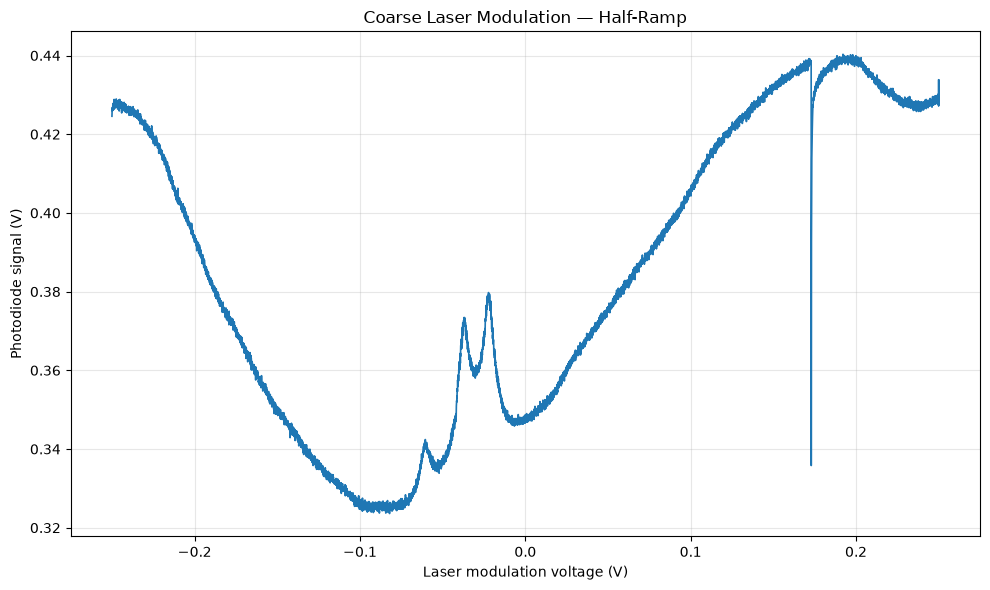

In [ ]:
# ============================================================
# CELL 2 — COARSE CENTERED HALF-RAMP
# ============================================================

# ------------------------------------------------------------
# USER SETTINGS
# ------------------------------------------------------------

SWEEP_RANGE_V = 0.8

# Center is fixed at 0 V for the coarse scan.
CENTER_V = 0.0

SWEEP_TIME_S = 5.0


# ------------------------------------------------------------
# CALCULATE SWEEP LIMITS
# ------------------------------------------------------------

START_V = CENTER_V - SWEEP_RANGE_V / 2.0
END_V   = CENTER_V + SWEEP_RANGE_V / 2.0


print()
print("============================================================")
print("COARSE HALF-RAMP")
print("============================================================")

print()
print(f"Center:       {CENTER_V:+.3f} V")
print(f"Range:        {SWEEP_RANGE_V:.3f} V")
print(f"Start:        {START_V:+.3f} V")
print(f"End:          {END_V:+.3f} V")
print(f"Sweep time:   {SWEEP_TIME_S:.3f} s")


# ------------------------------------------------------------
# CONFIGURE ASG
# ------------------------------------------------------------

# PyRPL's halframp is normalized from -1 to +1.
#
# amplitude = total voltage range / 2
# offset    = center voltage
#
# Therefore:
#
#   range = 1 V
#   center = 0 V
#
# gives:
#
#   -0.5 V -> +0.5 V
#

amplitude = SWEEP_RANGE_V / 2.0
offset = CENTER_V

frequency = 1.0 / SWEEP_TIME_S

asg.output_direct = "off"

asg.setup(
    waveform="halframp",
    frequency=frequency,
    amplitude=amplitude,
    offset=offset,
    trigger_source="immediately",
)

print()
print("ASG:")
print(f"  Waveform:   halframp")
print(f"  Amplitude:  {amplitude:.6f} V")
print(f"  Offset:     {offset:.6f} V")
print(f"  Frequency:  {frequency:.6f} Hz")


# ------------------------------------------------------------
# CONFIGURE SCOPE
# ------------------------------------------------------------

scope.input1 = "in1"
scope.input2 = "off"

scope.ch1_active = True
scope.ch2_active = False

scope.average = False
scope.trace_average = 1

scope.run_continuous = False
scope.rolling_mode = False

scope.trigger_source = "immediately"
scope.trigger_delay = 0


# ------------------------------------------------------------
# ARM SCOPE
# ------------------------------------------------------------

print()
print("Arming scope...")

scope_future = scope.single_async()

time.sleep(0.05)


# ------------------------------------------------------------
# START HALF-RAMP
# ------------------------------------------------------------

print("Connecting ASG0 -> OUT1...")

asg.output_direct = "out1"

print("Starting half-ramp...")


# ------------------------------------------------------------
# ACQUIRE
# ------------------------------------------------------------

try:

    raw_data = wait(
        scope_future,
        timeout=scope.duration + 5.0,
    )

except Exception:

    asg.output_direct = "off"
    raise


print("Acquisition complete.")


# ------------------------------------------------------------
# EXTRACT IN1
# ------------------------------------------------------------

raw_data = np.asarray(raw_data, dtype=float)

print(f"Raw scope data shape: {raw_data.shape}")

if raw_data.ndim == 2:

    if raw_data.shape[0] == 2:
        pd_data = raw_data[0]

    elif raw_data.shape[1] == 2:
        pd_data = raw_data[:, 0]

    else:
        asg.output_direct = "off"
        raise RuntimeError(
            f"Unexpected scope data shape: {raw_data.shape}"
        )

elif raw_data.ndim == 1:

    pd_data = raw_data

else:

    asg.output_direct = "off"
    raise RuntimeError(
        f"Unexpected scope data shape: {raw_data.shape}"
    )

pd_data = np.asarray(pd_data).reshape(-1)


# ------------------------------------------------------------
# TIME AXIS
# ------------------------------------------------------------

time_data = np.asarray(
    scope.times,
    dtype=float,
).reshape(-1)

time_data -= time_data[0]


# ------------------------------------------------------------
# VOLTAGE AXIS
# ------------------------------------------------------------

voltage_data = (
    START_V
    + SWEEP_RANGE_V
    * time_data
    / SWEEP_TIME_S
)

voltage_data = np.clip(
    voltage_data,
    START_V,
    END_V,
)


# ------------------------------------------------------------
# TURN OFF OUTPUT
# ------------------------------------------------------------

asg.output_direct = "off"


# ------------------------------------------------------------
# RESULTS
# ------------------------------------------------------------

print()
print("============================================================")
print("COARSE SWEEP COMPLETE")
print("============================================================")

print(f"Samples:       {len(pd_data)}")
print(
    f"Voltage:       "
    f"{voltage_data[0]:+.4f} -> "
    f"{voltage_data[-1]:+.4f} V"
)

print(
    f"PD signal:     "
    f"{np.min(pd_data):.6f} -> "
    f"{np.max(pd_data):.6f} V"
)


# ------------------------------------------------------------
# PLOT
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.plot(
    voltage_data,
    pd_data,
    linewidth=1.2,
)

plt.xlabel("Laser modulation voltage (V)")
plt.ylabel("Photodiode signal (V)")

plt.title("Coarse Laser Modulation — Half-Ramp")

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


FINE HALF-RAMP

Center:       -0.0500 V
Range:        0.1000 V
Start:        -0.1000 V
End:          +0.0000 V
Sweep time:   5.000 s

ASG:
  Waveform:   halframp
  Amplitude:  0.050000 V
  Offset:     -0.050000 V
  Frequency:  0.200000 Hz

Arming scope...
Connecting ASG0 -> OUT1...
Starting fine half-ramp...
Acquisition complete.
Raw scope data shape: (2, 16384)

FINE SWEEP COMPLETE
Samples:       16384
Voltage:       -0.10000 -> +0.00000 V

Measured maximum:
  Voltage:     -0.015527 V
  PD signal:   0.339233 V


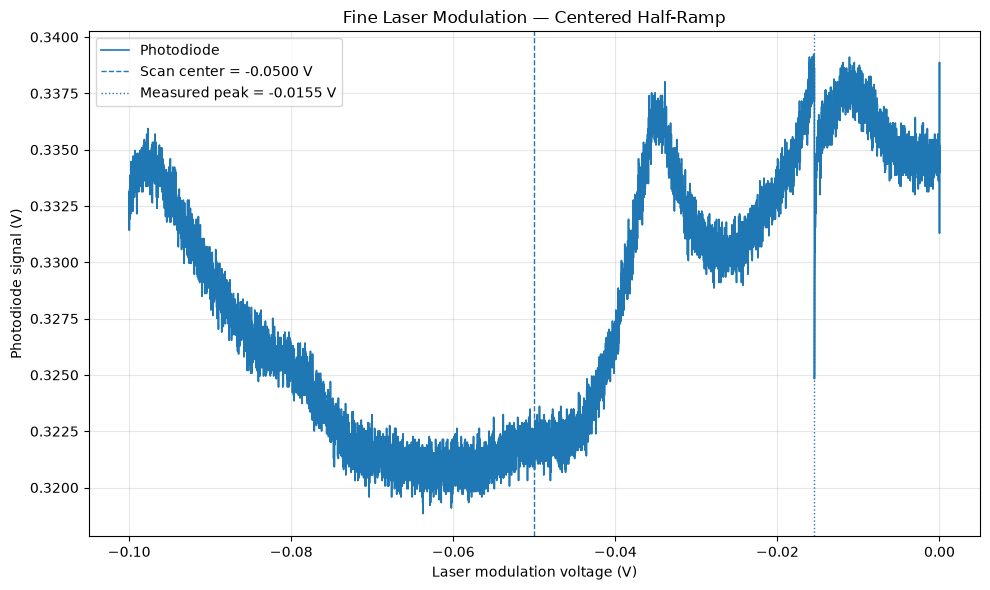

In [7]:
# ============================================================
# CELL 3 — FINE CENTERED HALF-RAMP
# ============================================================

# ------------------------------------------------------------
# USER SETTINGS
# ------------------------------------------------------------

# Center of the fine scan.
CENTER_V = -0.05

# Total width of the scan.
#
# Example:
#   0.10 V range centered at 0.25 V
#
# gives:
#   0.20 V -> 0.30 V
#
SWEEP_RANGE_V = 0.10

SWEEP_TIME_S = 5.0


# ------------------------------------------------------------
# CALCULATE LIMITS
# ------------------------------------------------------------

START_V = CENTER_V - SWEEP_RANGE_V / 2.0
END_V   = CENTER_V + SWEEP_RANGE_V / 2.0


if START_V < -1.0 or END_V > 1.0:
    raise ValueError(
        f"Sweep range is outside the Red Pitaya ±1 V output range: "
        f"{START_V:.3f} -> {END_V:.3f} V"
    )


print()
print("============================================================")
print("FINE HALF-RAMP")
print("============================================================")

print()
print(f"Center:       {CENTER_V:+.4f} V")
print(f"Range:        {SWEEP_RANGE_V:.4f} V")
print(f"Start:        {START_V:+.4f} V")
print(f"End:          {END_V:+.4f} V")
print(f"Sweep time:   {SWEEP_TIME_S:.3f} s")


# ------------------------------------------------------------
# CONFIGURE ASG
# ------------------------------------------------------------

amplitude = SWEEP_RANGE_V / 2.0
offset = CENTER_V

frequency = 1.0 / SWEEP_TIME_S

asg.output_direct = "off"

asg.setup(
    waveform="halframp",
    frequency=frequency,
    amplitude=amplitude,
    offset=offset,
    trigger_source="immediately",
)

print()
print("ASG:")
print(f"  Waveform:   halframp")
print(f"  Amplitude:  {amplitude:.6f} V")
print(f"  Offset:     {offset:.6f} V")
print(f"  Frequency:  {frequency:.6f} Hz")


# ------------------------------------------------------------
# CONFIGURE SCOPE
# ------------------------------------------------------------

scope.input1 = "in1"
scope.input2 = "off"

scope.ch1_active = True
scope.ch2_active = False

scope.average = False
scope.trace_average = 1

scope.run_continuous = False
scope.rolling_mode = False

scope.trigger_source = "immediately"
scope.trigger_delay = 0


# ------------------------------------------------------------
# ARM
# ------------------------------------------------------------

print()
print("Arming scope...")

scope_future = scope.single_async()

time.sleep(0.05)


# ------------------------------------------------------------
# START SWEEP
# ------------------------------------------------------------

print("Connecting ASG0 -> OUT1...")

asg.output_direct = "out1"

print("Starting fine half-ramp...")


# ------------------------------------------------------------
# ACQUIRE
# ------------------------------------------------------------

try:

    raw_data = wait(
        scope_future,
        timeout=scope.duration + 5.0,
    )

except Exception:

    asg.output_direct = "off"
    raise


print("Acquisition complete.")


# ------------------------------------------------------------
# EXTRACT IN1
# ------------------------------------------------------------

raw_data = np.asarray(raw_data, dtype=float)

print(f"Raw scope data shape: {raw_data.shape}")

if raw_data.ndim == 2:

    if raw_data.shape[0] == 2:
        pd_data = raw_data[0]

    elif raw_data.shape[1] == 2:
        pd_data = raw_data[:, 0]

    else:
        asg.output_direct = "off"
        raise RuntimeError(
            f"Unexpected scope data shape: {raw_data.shape}"
        )

elif raw_data.ndim == 1:

    pd_data = raw_data

else:

    asg.output_direct = "off"
    raise RuntimeError(
        f"Unexpected scope data shape: {raw_data.shape}"
    )

pd_data = np.asarray(pd_data).reshape(-1)


# ------------------------------------------------------------
# TIME
# ------------------------------------------------------------

time_data = np.asarray(
    scope.times,
    dtype=float,
).reshape(-1)

time_data -= time_data[0]


# ------------------------------------------------------------
# VOLTAGE
# ------------------------------------------------------------

voltage_data = (
    START_V
    + SWEEP_RANGE_V
    * time_data
    / SWEEP_TIME_S
)

voltage_data = np.clip(
    voltage_data,
    START_V,
    END_V,
)


# ------------------------------------------------------------
# TURN OFF OUTPUT
# ------------------------------------------------------------

asg.output_direct = "off"


# ------------------------------------------------------------
# FIND PEAK
# ------------------------------------------------------------

peak_index = np.argmax(pd_data)

peak_voltage = voltage_data[peak_index]
peak_signal = pd_data[peak_index]


# ------------------------------------------------------------
# RESULTS
# ------------------------------------------------------------

print()
print("============================================================")
print("FINE SWEEP COMPLETE")
print("============================================================")

print(f"Samples:       {len(pd_data)}")

print(
    f"Voltage:       "
    f"{voltage_data[0]:+.5f} -> "
    f"{voltage_data[-1]:+.5f} V"
)

print()
print("Measured maximum:")
print(f"  Voltage:     {peak_voltage:+.6f} V")
print(f"  PD signal:   {peak_signal:.6f} V")


# ------------------------------------------------------------
# PLOT
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.plot(
    voltage_data,
    pd_data,
    linewidth=1.2,
    label="Photodiode",
)

plt.axvline(
    CENTER_V,
    linestyle="--",
    linewidth=1,
    label=f"Scan center = {CENTER_V:+.4f} V",
)

plt.axvline(
    peak_voltage,
    linestyle=":",
    linewidth=1,
    label=f"Measured peak = {peak_voltage:+.4f} V",
)

plt.xlabel("Laser modulation voltage (V)")
plt.ylabel("Photodiode signal (V)")

plt.title("Fine Laser Modulation — Centered Half-Ramp")

plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()